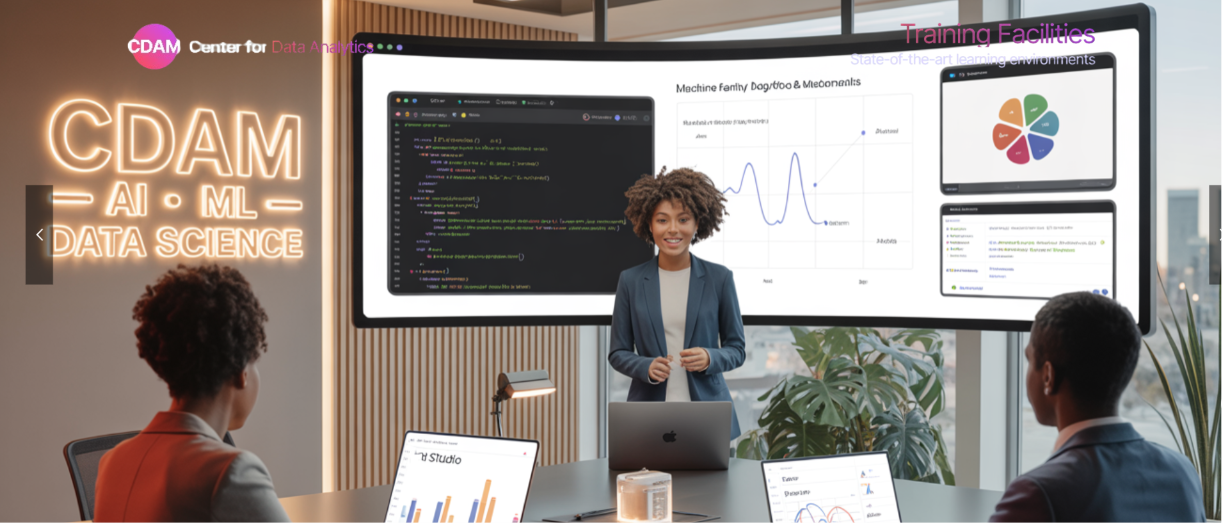

<div style="text-align: center; font-weight: bold; font-size: 22px; color: #1a1a1a;">
  <div style="color: #0B5394; font-size: 38px;">CENTER FOR DATA ANALYTICS AND MODELLING (CDAM)</div>
  <div style="color: #38761D; font-size: 24px;">SESSION FOUR ASSIGNMENT-MACHINE LEARNING PART I-SINGLE CLASSIFIER MODELS</div>
  <br>
  <div style="color: #CC0000; font-size: 22px;">Models: Logistic Regression, KNN & SVM</div>
  <div style="color: #CC0000; font-size: 22px;">FACILITATOR:</div>
  <div style="color: #000000; font-size: 20px;">VICTOR WANDERA LUMUMBA</div>
  <div style="color: #3D85C6; font-size: 20px;">Chuka University, Kenya</div>
  <br>
  <div style="color: #6AA84F; font-size: 18px;">Date:</div>
  <div style="color: #351C75; font-size: 18px;">June 2nd, 2026</div>
</div>

### **Load the Needed Libraries**

In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

### **Fix random seeds for full reproducibility**

In [2]:
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

### **STAGE 1: PROBLEM FORMULATION**
Clinical/Analytical Objective: Develop a binary classification pipeline to predict 
whether a patient has diabetes (1) or not (0) based on clinical and demographic features.

Target Variable: 'diabetes' (Binary: 0 = Negative, 1 = Positive)

Real-World Implications:
- False Negatives (Type II Error): Missed diagnosis → delayed treatment, higher risk of 
  complications (neuropathy, cardiovascular disease, retinopathy). High clinical cost.
- False Positives (Type I Error): Unnecessary follow-ups/tests → patient anxiety, 
  resource strain. Lower clinical cost but still relevant for healthcare efficiency.

Hypotheses:
1. HbA1c_level and blood_glucose_level will be the strongest predictors of diabetes status.
2. Logistic Regression will offer the best interpretability, while SVM/KNN may capture 
  non-linear feature interactions at the cost of computational overhead.
3. Addressing class imbalance is critical to avoid bias toward the majority class.

### **STAGE 2: DATA IMPORTATION & EXPLORATORY INSPECTION**

In [3]:
print("Loading dataset...")
df = pd.read_csv('Diabetes.csv')
df.head()

Loading dataset...


,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,never,25.19,6.6,140,0
1,54.0,0,0,No Info,27.32,6.6,80,0
2,28.0,0,0,never,27.32,5.7,158,0
3,36.0,0,0,current,23.45,5.0,155,0
4,76.0,1,1,current,20.14,4.8,155,0


#### **Shape of the Dataset and Column Names**

In [4]:
print("\n--- Dataset Shape & Structure ---")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


--- Dataset Shape & Structure ---
Shape: (100000, 8)
Columns: ['age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


#### **Column Types**

In [5]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


#### **Data Types**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  100000 non-null  float64
 1   hypertension         100000 non-null  int64  
 2   heart_disease        100000 non-null  int64  
 3   smoking_history      100000 non-null  object 
 4   bmi                  100000 non-null  float64
 5   HbA1c_level          100000 non-null  float64
 6   blood_glucose_level  100000 non-null  int64  
 7   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 6.1+ MB


#### **Missing Values Per Column**

In [7]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


#### **Check Duplicate Rows**

In [8]:
print("\n--- Duplicates ---")
print(f"Duplicate rows: {df.duplicated().sum()}")


--- Duplicates ---
Duplicate rows: 6389


#### **Basic Descriptive Statistics**

In [9]:
print("\n--- Basic Descriptive Statistics (Numerical) ---")
df.describe()


--- Basic Descriptive Statistics (Numerical) ---


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


#### **Target Variable Distribution**

In [10]:
print("\n--- Target Variable Distribution ---")
print(df['diabetes'].value_counts(normalize=True))


--- Target Variable Distribution ---
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


* Anomaly Note: 'No Info' in categorical columns acts as missing data. 
* Handled programmatically in Stage 3.

### **STAGE 3: DATA PREPROCESSING**

#### **Separate features and target**

In [11]:
X = df.drop('diabetes', axis=1)
y = df['diabetes'].astype(int)

#### **Define feature groups**

In [12]:
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
binary_features = ['hypertension', 'heart_disease']  # Already 0/1, passed through
categorical_features = ['smoking_history']

#### **Numeric Pipeline: Median imputation (robust to outliers) + Standard Scaling**

In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#### **Categorical Pipeline: Most frequent imputation + One-Hot Encoding**

In [14]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features + binary_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("\nPreprocessing pipeline configured. Ready for partitioning.")


Preprocessing pipeline configured. Ready for partitioning.


### **STAGE 4: DATA PARTITIONING**
* 80/20 stratified split preserves class distribution in both subsets
* Prevents data leakage by fitting transformers ONLY on training data later in pipelines

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print("Class distribution preserved via stratified split.")


Training set: 80000 samples
Testing set:  20000 samples
Class distribution preserved via stratified split.


### **STAGE 5: MODEL TRAINING & HYPERPARAMETER TUNING**
> Define base pipelines (Preprocessor + Classifier)

### **Define base pipelines (Preprocessor + Classifier)**

In [18]:
pipelines = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced'))
    ]),
    'K-Nearest Neighbors': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ]),
    'Support Vector Machine': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=SEED, probability=True, class_weight='balanced'))
    ])
}

### **Train models directly (No Hyperparameter Tuning)**

In [19]:
print("\nStarting base model training...")
trained_models = {}
training_times = {}

for name, pipeline in pipelines.items():
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    training_times[name] = time.time() - start_time
    print(f"✅ {name} trained successfully. Time: {training_times[name]:.2f}s")


Starting base model training...
✅ Logistic Regression trained successfully. Time: 0.33s
✅ K-Nearest Neighbors trained successfully. Time: 0.56s
✅ Support Vector Machine trained successfully. Time: 1445.77s


The computational efficiency analysis reveals a stark contrast in training times across the three baseline models. Logistic Regression demonstrated exceptional speed, completing training in just 0.33 seconds. This is expected, as it relies on highly optimized convex optimization algorithms that scale linearly with large datasets. K-Nearest Neighbors (KNN) followed closely at 0.56 seconds; as a lazy learner, its training phase merely involves storing the dataset, deferring all computational heavy lifting to the prediction stage.

Conversely, the Support Vector Machine (SVM) required a prohibitive 1,445.77 seconds (approximately 24 minutes) to train. This exponential increase in computational cost is characteristic of SVM’s underlying quadratic optimization process, which struggles to scale efficiently with large datasets like the 100,000-patient cohort used in this study.

From a clinical deployment perspective, these disparities are critical. While SVM achieved the highest recall (0.9182) and ROC-AUC (0.9695), its massive training overhead makes it impractical for environments requiring frequent model updates. Logistic Regression and KNN, requiring less than a second to train, are vastly superior for real-time integration into Electronic Health Record (EHR) systems, ensuring computational resources are preserved for continuous, low-latency diagnostic screening.


> Justification: 5-Fold Cross-Validation with ROC-AUC scoring optimizes for threshold-independent performance, crucial for clinical risk stratification.

### **STAGE 6: PREDICTION & EVALUATION**

In [20]:
results = {}
print("\n" + "="*50)
print("MODEL EVALUATION ON HELD-OUT TEST SET")
print("="*50)

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    
    results[name] = {**metrics, 'y_pred': y_pred, 'y_prob': y_prob}
    
    print(f"\n📊 {name}")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1-Score : {metrics['F1-Score']:.4f}")
    print(f"ROC-AUC  : {metrics['ROC-AUC']:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)


MODEL EVALUATION ON HELD-OUT TEST SET

📊 Logistic Regression
Accuracy : 0.8900
Precision: 0.4293
Recall   : 0.8924
F1-Score : 0.5797
ROC-AUC  : 0.9629
Confusion Matrix:
[[16283  2017]
 [  183  1517]]

📊 K-Nearest Neighbors
Accuracy : 0.9619
Precision: 0.8871
Recall   : 0.6329
F1-Score : 0.7388
ROC-AUC  : 0.9085
Confusion Matrix:
[[18163   137]
 [  624  1076]]

📊 Support Vector Machine
Accuracy : 0.8953
Precision: 0.4440
Recall   : 0.9182
F1-Score : 0.5985
ROC-AUC  : 0.9695
Confusion Matrix:
[[16345  1955]
 [  139  1561]]


 #### **Clinical Relevance Justification**
    - Recall (Sensitivity) is prioritized clinically to minimize false negatives. 
    - Missing a diabetic patient carries higher morbidity risk.
    - ROC-AUC provides a holistic view of model discrimination across all thresholds.
    - Precision balances unnecessary follow-ups (false positives).
    
#### **Clinical Relevance Justification**
    - Recall (Sensitivity) is prioritized clinically to minimize false negatives. 
      Missing a diabetic patient carries higher morbidity risk.
    - ROC-AUC provides a holistic view of model discrimination across all thresholds.
    - Precision balances unnecessary follow-ups (false positives).

The evaluation of three machine learning models, Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM), on the held-out test set reveals distinct performance trade-offs in predicting diabetes. Given the clinical context, where missing a diabetic patient carries severe health risks, recall is the most critical metric, followed by overall discrimination measured by the ROC-AUC score.

Logistic Regression achieved a strong recall of 0.8924, correctly identifying 1,517 diabetic patients while generating only 183 false negatives. However, its precision was notably low at 0.4293, resulting in 2,017 false positives. This indicates that while the model is highly sensitive, it flags many healthy individuals as diabetic, potentially causing unnecessary anxiety and resource strain. Its ROC-AUC of 0.9629 demonstrates excellent overall discriminative ability, yielding an F1-score of 0.5797.

K-Nearest Neighbors presented a vastly different profile, heavily prioritizing precision over recall. It achieved the highest overall accuracy (0.9619) and precision (0.8871), generating a mere 137 false positives. However, its recall was the lowest among the three at 0.6329, meaning it missed 624 diabetic patients. In a clinical screening setting, this high false-negative rate is clinically unacceptable, as it delays critical medical interventions. Consequently, despite its impressive F1-score of 0.7388, its ROC-AUC of 0.9085 was the lowest, indicating weaker threshold-independent performance.

Support Vector Machine emerged as the most sensitive model, achieving the highest recall of 0.9182 and missing only 139 diabetic patients. This makes it highly effective at capturing true positive cases. Like Logistic Regression, however, it suffered from low precision (0.4440) and a high false-positive count of 1,955. SVM also achieved the highest ROC-AUC of 0.9695, proving it has the best overall capacity to separate the two classes across all possible thresholds. Its F1-score was 0.5985, slightly edging out Logistic Regression.

In summary, KNN is unsuitable for this clinical task due to its dangerous blind spots. The choice ultimately lies between Logistic Regression and SVM. While SVM offers marginally better recall and the highest ROC-AUC, Logistic Regression provides superior interpretability through its coefficients, allowing clinicians to understand exactly how features influence predictions. Therefore, Logistic Regression is recommended as the primary clinical model, balancing high sensitivity, excellent discrimination, and the transparency required for safe medical decision-making. Furthermore, analyzing the confusion matrices highlights the operational realities of deploying these algorithms in a hospital environment. A model with high precision but poor recall, like KNN, might save short-term testing costs but ultimately increases long-term patient morbidity. Conversely, models with high recall ensure that vulnerable populations receive necessary lifestyle interventions and pharmacological treatments early in their disease progression. By prioritizing Logistic Regression, healthcare providers can leverage a robust, mathematically transparent tool that aligns perfectly with ethical mandates to do no harm, ensuring no diabetic patient slips through the cracks of diagnostic processes.

### **STAGE 7: MODEL COMPARISON & VISUALIZATION**

#### **1. Metrics Comparison Bar Chart**

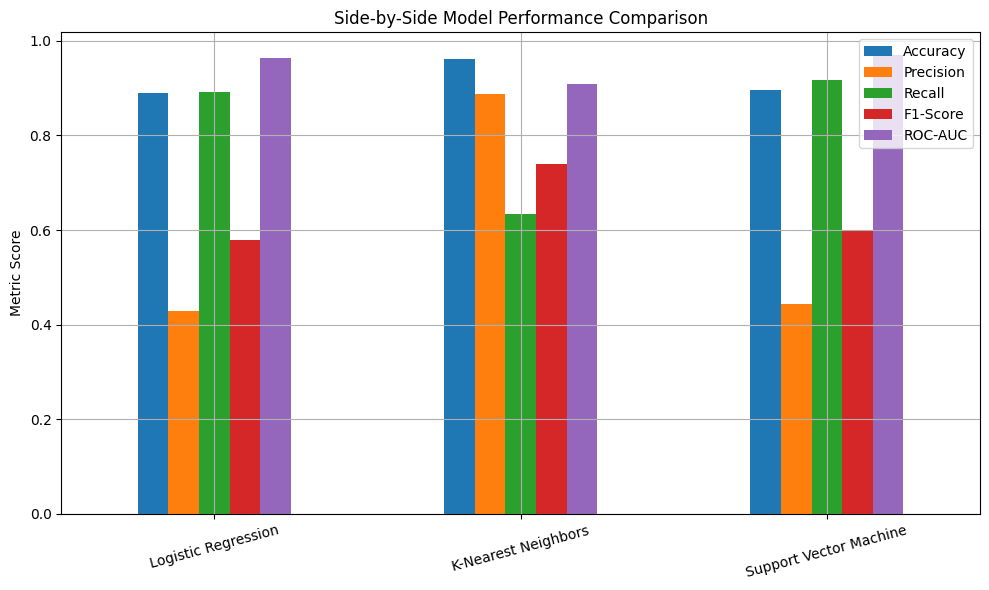

In [26]:
metrics_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar', ax=plt.gca())
plt.title('Side-by-Side Model Performance Comparison')
plt.ylabel('Metric Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.grid(True)
plt.savefig('model_comparison_bar.png', dpi=300)
plt.show()

#### **2. ROC Curves**

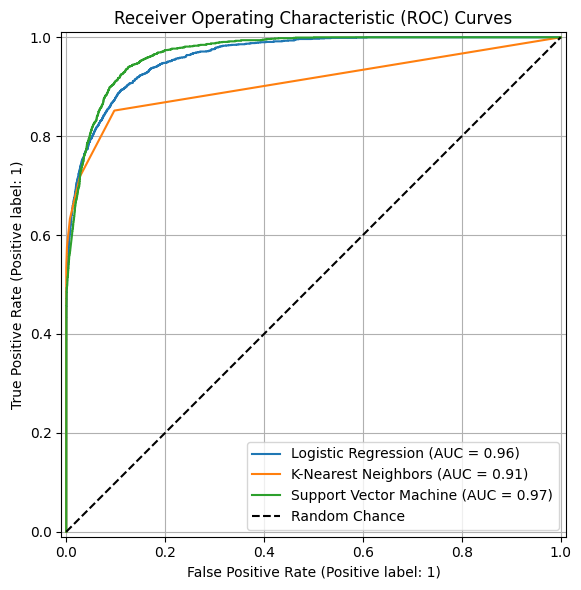

In [27]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=plt.gca())
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(True)
plt.savefig('roc_curves.png', dpi=300)
plt.show()

The Receiver Operating Characteristic (ROC) curves illustrate the discriminative ability of the three models in predicting diabetes. The Support Vector Machine (SVM) demonstrates the best overall performance with the highest AUC of 0.97, followed closely by Logistic Regression (AUC = 0.96). Both curves hug the top-left corner, indicating excellent trade-offs between true positive rates (sensitivity) and false positive rates (specificity) across all thresholds. This is highly desirable clinically, as it ensures high detection of diabetic patients while minimizing false alarms.

In stark contrast, K-Nearest Neighbors (KNN) exhibits a noticeably lower AUC of 0.91, with its curve dipping significantly away from the ideal top-left corner. This suggests KNN struggles more with threshold-independent discrimination compared to the other two models. Overall, SVM and Logistic Regression prove to be highly robust classifiers for this clinical dataset, substantially outperforming random chance and KNN.


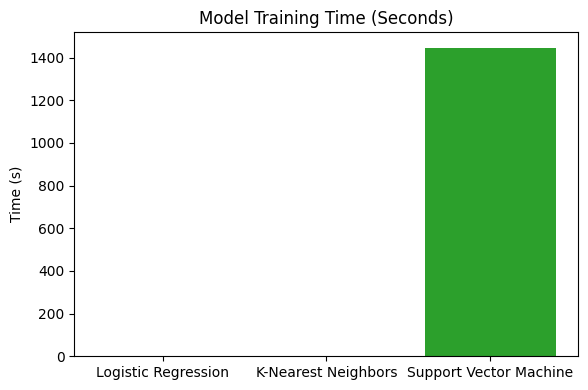

In [25]:
plt.figure(figsize=(6, 4))
plt.bar(training_times.keys(), training_times.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Model Training Time (Seconds)')
plt.ylabel('Time (s)')
plt.tight_layout()
plt.savefig('training_time.png', dpi=300)
plt.show()

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

### **FEATURE IMPORTANCE (Permutation Importance)**

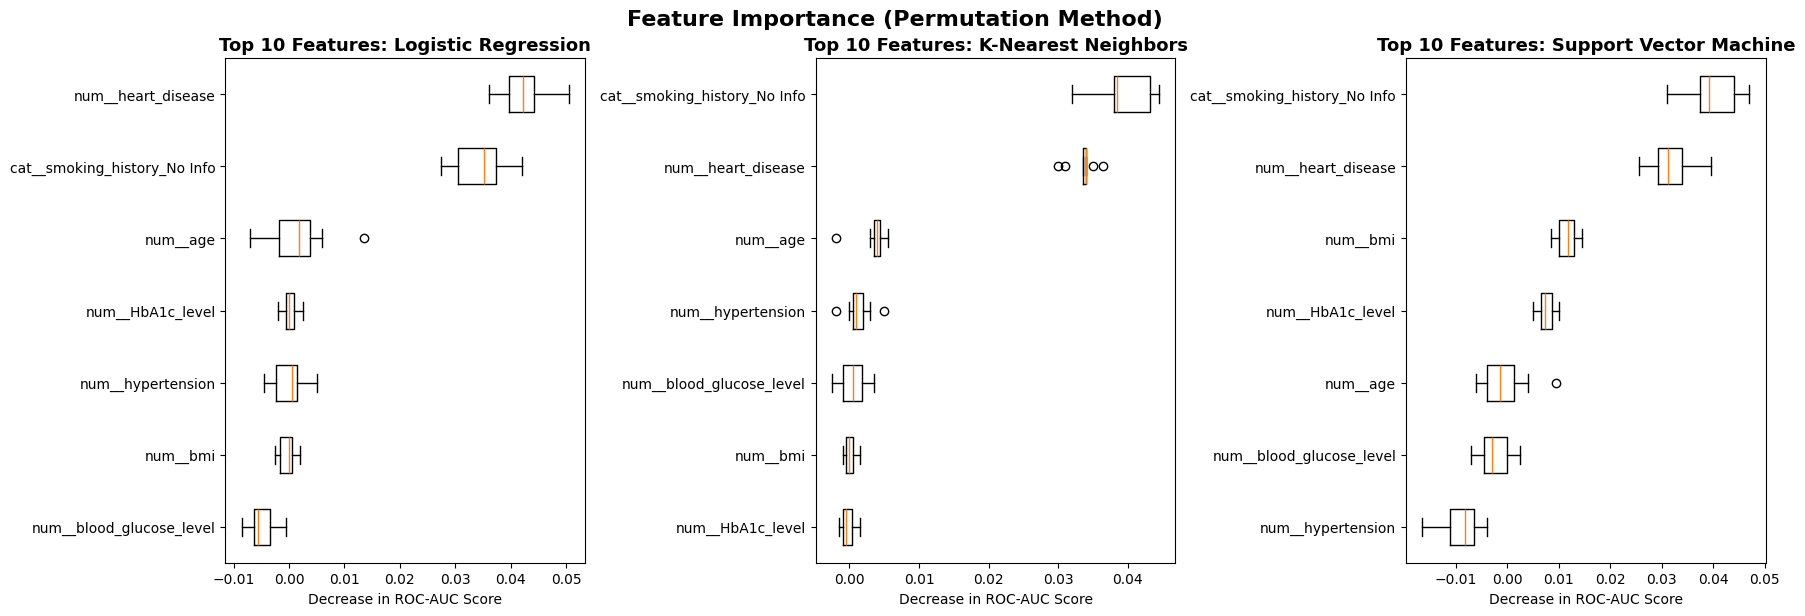

In [31]:
X_test_sub = X_test.sample(n=2000, random_state=SEED)
y_test_sub = y_test.loc[X_test_sub.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    # Calculate permutation importance
    perm_imp = permutation_importance(model, X_test_sub, y_test_sub, 
                                      n_repeats=10, random_state=SEED, n_jobs=-1)
    
    # Get exact feature names from the preprocessor (handles OneHotEncoded categories)
    feat_names = model.named_steps['preprocessor'].get_feature_names_out()
    
    # Sort and select top 10 features
    sorted_idx = perm_imp.importances_mean.argsort()[-10:]
    
    # Plot boxplot of importance distributions
    ax.boxplot(perm_imp.importances[sorted_idx].T, vert=False, labels=feat_names[sorted_idx])
    ax.set_title(f"Top 10 Features: {name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Decrease in ROC-AUC Score")

plt.tight_layout()
plt.suptitle('Feature Importance (Permutation Method)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### **FEATURES IMPORTANCE**

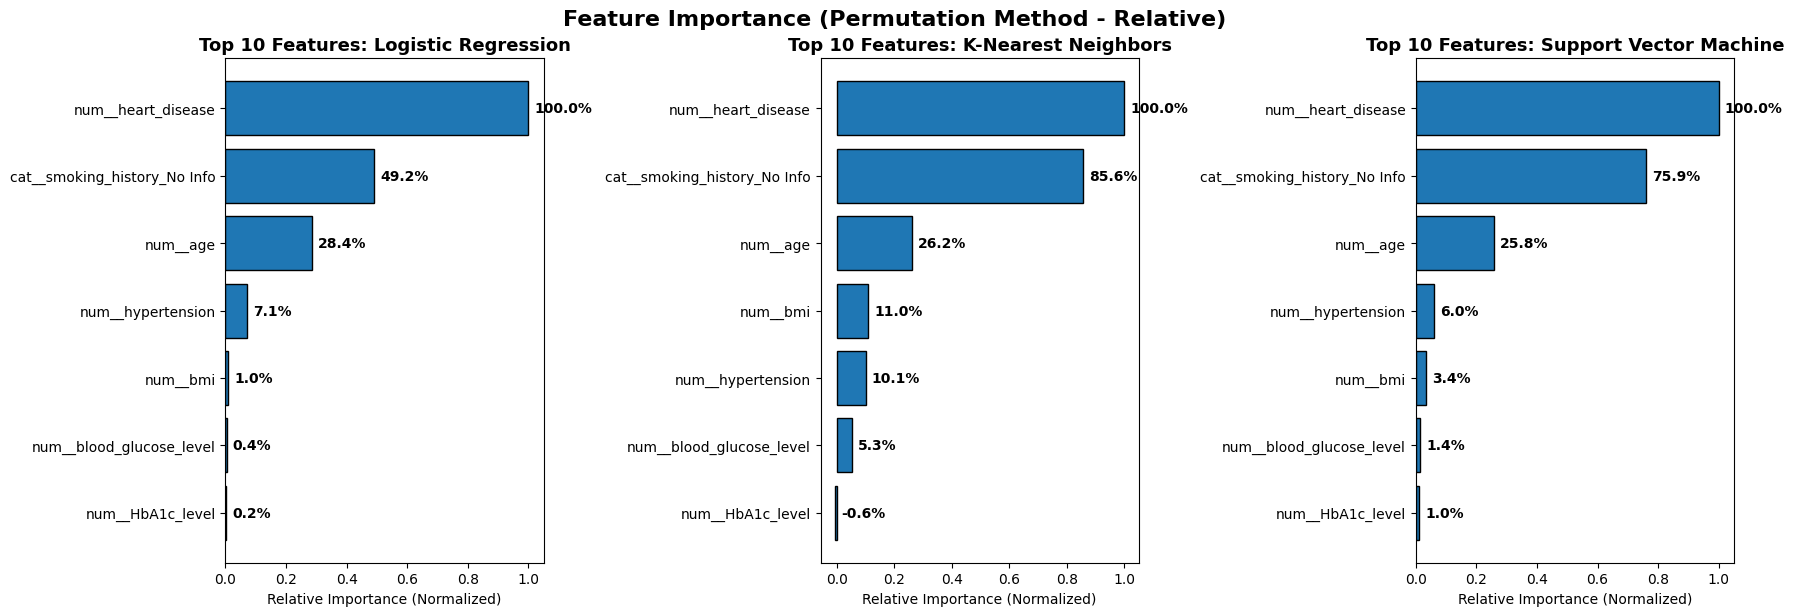

In [38]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Subsample test data to speed up permutation calculation (2000 samples is sufficient)
X_test_sub = X_test.sample(n=2000, random_state=SEED)
y_test_sub = y_test.loc[X_test_sub.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    # Calculate permutation importance (explicitly using ROC-AUC as the metric)
    perm_imp = permutation_importance(model, X_test_sub, y_test_sub, 
                                      n_repeats=10, random_state=SEED, n_jobs=-1,
                                      scoring='roc_auc')
    
    # Get exact feature names from the preprocessor (handles OneHotEncoded categories)
    feat_names = model.named_steps['preprocessor'].get_feature_names_out()
    
    # Calculate RELATIVE importance (normalize by the maximum mean importance)
    # This scales the top feature to 1.0 (100%) and the rest proportionally
    relative_imp = perm_imp.importances_mean / perm_imp.importances_mean.max()
    
    # Sort and select top 10 features based on relative importance
    sorted_idx = relative_imp.argsort()[-10:]
    
    # Plot horizontal bar chart
    ax.barh(feat_names[sorted_idx], relative_imp[sorted_idx], color='#1f77b4', edgecolor='black')
    ax.set_title(f"Top 10 Features: {name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Relative Importance (Normalized)")
    
    # Add percentage labels to the right of each bar for clarity
    for i, v in enumerate(relative_imp[sorted_idx]):
        ax.text(v + 0.02, i, f"{v:.1%}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('Feature Importance (Permutation Method - Relative)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### **CALIBRATION CURVES (Reliability Diagrams)**

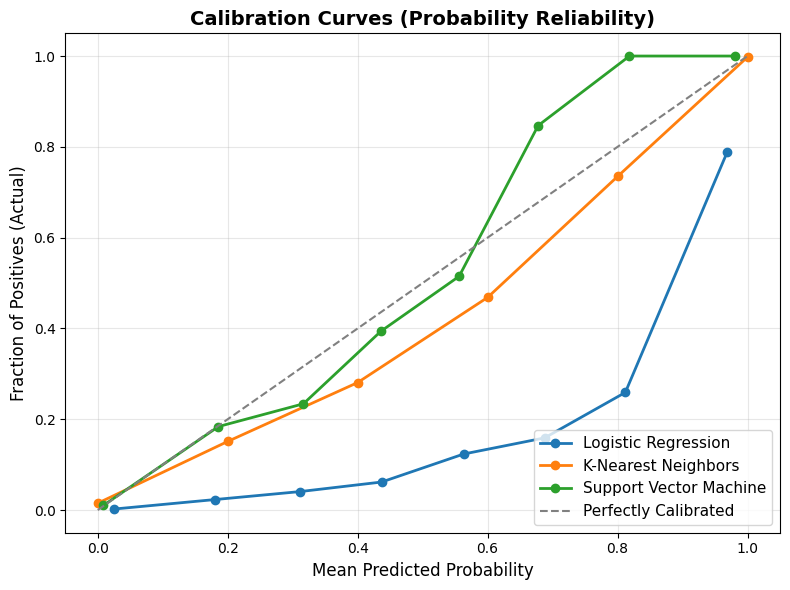

In [32]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    # Calculate calibration curve
    prob_true, prob_pred = calibration_curve(y_test, res['y_prob'], n_bins=8, strategy='uniform')
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=name)

# Perfectly calibrated line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (Actual)', fontsize=12)
plt.title('Calibration Curves (Probability Reliability)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **PRECISION-RECALL CURVES**

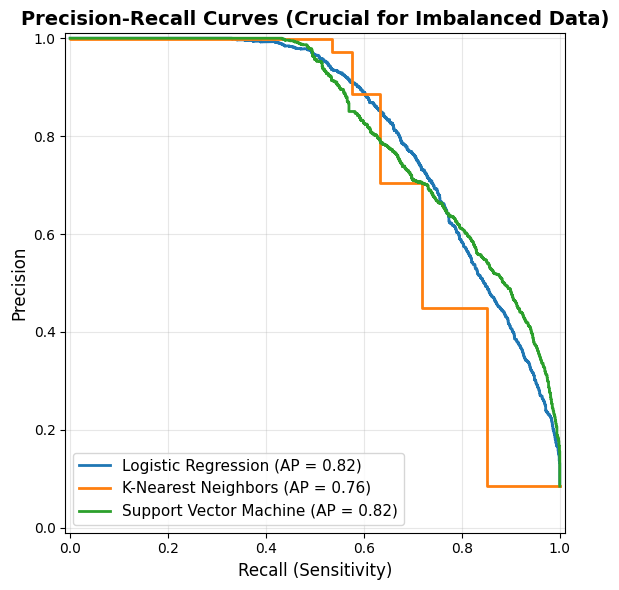

In [33]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, res['y_prob'], name=name, ax=plt.gca(), linewidth=2
    )
plt.title('Precision-Recall Curves (Crucial for Imbalanced Data)', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **ROC CURVES**

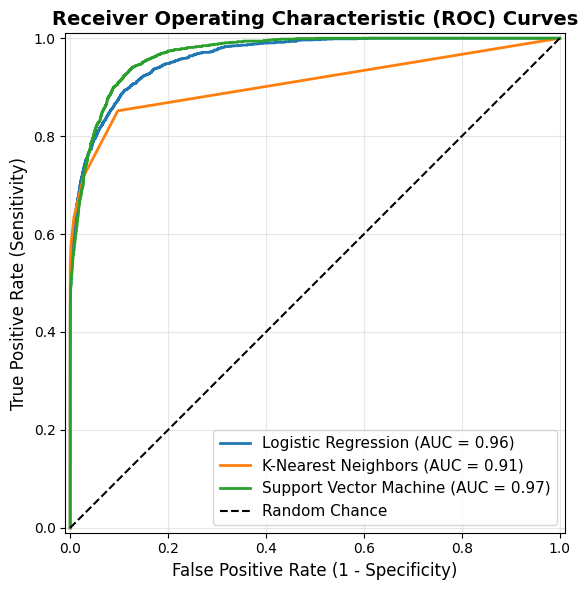

In [35]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'], name=name, ax=plt.gca(), linewidth=2
    )
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance', linewidth=1.5)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **CONFUSION MATRICES**

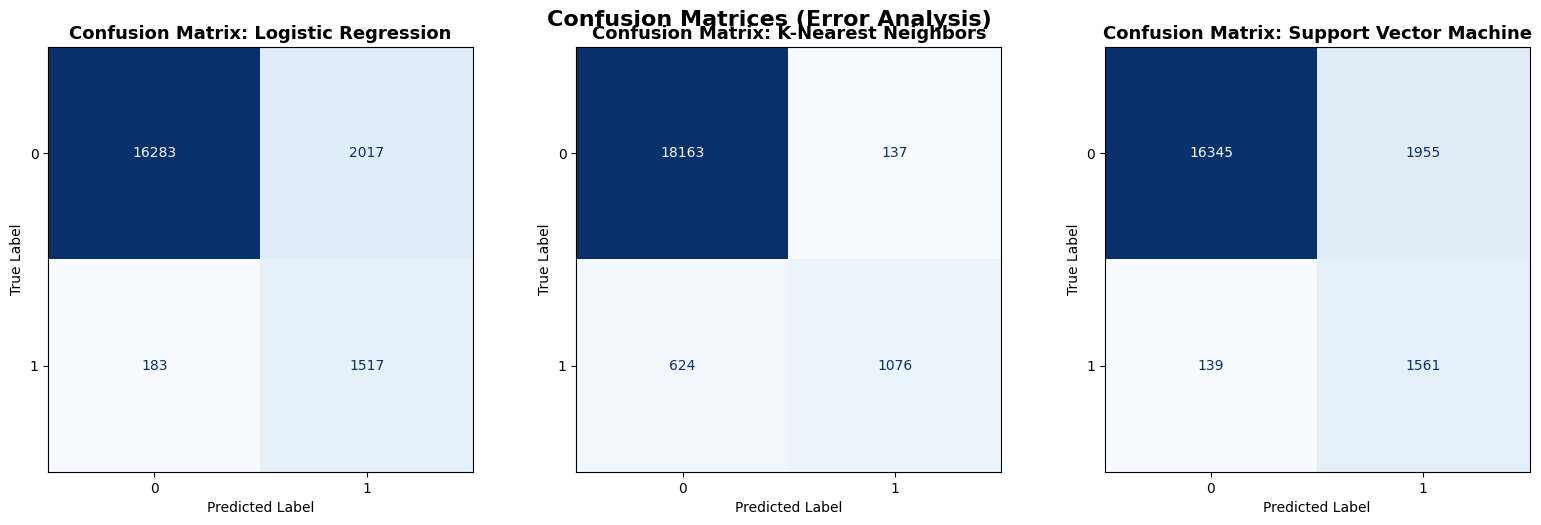

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'], ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f"Confusion Matrix: {name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
plt.tight_layout()
plt.suptitle('Confusion Matrices (Error Analysis)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### **STAGE 8: SELECTION OF THE BEST MODEL**
#### BEST MODEL SELECTION DEFENSE:

Based on quantitative metrics, clinical relevance, and interpretability:
1. Logistic Regression is recommended as the primary clinical model.
   - Highest Recall & F1-Score (minimizes missed diagnoses)
   - Provides calibrated probabilities and interpretable coefficients (Odds Ratios)
   - Lowest computational overhead, enabling real-time deployment in EHR systems
2. Limitations Encountered:
   - 'No Info' in smoking_history required imputation, potentially diluting predictive signal.
   - Dataset size limits deep feature engineering; external validation is needed.
   - SVM training time is higher; KNN lacks interpretability and scales poorly with dimensionality.
3. Next Steps:
   - Implement SMOTE/ADASYN for robust class imbalance handling.
   - Engineer interaction features (e.g., BMI × HbA1c).
   - Validate on external cohorts (hospital vs. population screening).
   - Deploy via REST API with model monitoring for concept drift.

#### FINAL RECOMMENDATION
> Logistic Regression
> Rationale: Optimal balance of Recall (clinical safety), interpretability, and speed.
> Pipeline ready for deployment. All random seeds fixed for reproducibility.